# Case Study: What Makes a Song Popular?
## Notebook 4 — Model Comparison: Linear Regression vs Random Forest vs XGBoost

**Building on Notebook 3**, which showed that `artist_avg_popularity` is the strongest predictor of track popularity.

This notebook keeps the same feature set (audio features + `artist_avg_popularity` + `year`) and asks:  
**Do tree-based models outperform linear regression on this dataset?**

| Model | Type | Notes |
|---|---|---|
| Linear Regression | Linear | Baseline from Notebook 3 |
| Random Forest | Tree ensemble | Captures non-linear patterns |
| XGBoost | Gradient boosting | Iteratively corrects errors |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
path = 'spotify_data 2.csv'
df = pd.read_csv(path)
print(f'Shape: {df.shape}')
df.head()

Shape: (169909, 19)


,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.995,['Carl Woitschach'],0.708,158648,0.1950,0,6KbQ3uYMLKb5jDxLF7wYDD,0.563,10,0.1510,-12.428,1,Singende Bataillone 1. Teil,0,1928,0.0506,118.469,0.7790,1928
1,0.994,"['Robert Schumann', 'Vladimir Horowitz']",0.379,282133,0.0135,0,6KuQTIu1KoTTkLXKrwlLPV,0.901,8,0.0763,-28.454,1,"Fantasiestücke, Op. 111: Più tosto lento",0,1928,0.0462,83.972,0.0767,1928
2,0.604,['Seweryn Goszczyński'],0.749,104300,0.2200,0,6L63VW0PibdM1HDSBoqnoM,0.000,5,0.1190,-19.924,0,Chapter 1.18 - Zamek kaniowski,0,1928,0.9290,107.177,0.8800,1928
3,0.995,['Francisco Canaro'],0.781,180760,0.1300,0,6M94FkXd15sOAOQYRnWPN8,0.887,1,0.1110,-14.734,0,Bebamos Juntos - Instrumental (Remasterizado),0,1928-09-25,0.0926,108.003,0.7200,1928
4,0.990,"['Frédéric Chopin', 'Vladimir Horowitz']",0.210,687733,0.2040,0,6N6tiFZ9vLTSOIxkj8qKrd,0.908,11,0.0980,-16.829,1,"Polonaise-Fantaisie in A-Flat Major, Op. 61",1,1928,0.0424,62.149,0.0693,1928


## 2. Feature Engineering — Artist Average Popularity

Same feature as Notebook 3: for each track, compute the mean popularity of all tracks by the same artist.  
This captures artist reputation as a single numeric feature.


In [3]:
import ast

# Extract primary artist (first name in the list)
def primary_artist(val):
    try:
        parsed = ast.literal_eval(val)
        return parsed[0] if isinstance(parsed, list) and len(parsed) > 0 else val
    except:
        return val

df['primary_artist'] = df['artists'].apply(primary_artist)

# Artist avg popularity = mean of top 10 most popular tracks per artist
# Using top 10 (not all tracks) so prolific artists with large back catalogs
# are not penalised — this captures hit-making ability
top10_mean = (
    df[df['popularity'] > 0]
    .groupby('primary_artist')['popularity']
    .apply(lambda x: x.nlargest(10).mean())
    .rename('artist_avg_popularity')
)
df = df.join(top10_mean, on='primary_artist')
df['artist_avg_popularity'] = df['artist_avg_popularity'].fillna(df['popularity'].median())

r = df['artist_avg_popularity'].corr(df['popularity'])
print(f'Correlation — artist_avg_popularity vs popularity: {r:.4f}')

# Spot check
for artist in ['Taylor Swift', 'Drake', 'Billie Eilish', 'Ed Sheeran']:
    val = top10_mean.get(artist)
    if val:
        print(f'  {artist}: {val:.1f}')

Correlation — artist_avg_popularity vs popularity: 0.9243


## 3. Select Features & Train-Test Split

Feature set: 13 audio features + `year` + `artist_avg_popularity`  
Target: `popularity`  
Split: 80% train / 20% test


In [4]:
drop_cols = ['id', 'name', 'artists', 'release_date', 'popularity']
X = df.drop(columns=drop_cols)
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Features: {X_train.shape[1]}')
print(f'Train:    {X_train.shape[0]:,} rows')
print(f'Test:     {X_test.shape[0]:,} rows')
print(f'\nFeature list: {list(X_train.columns)}')

Features: 15
Train:    135,927 rows
Test:     33,982 rows

Feature list: ['acousticness', 'danceability', 'duration_ms', 'energy', 'explicit', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'valence', 'year', 'artist_avg_popularity']


## 4. Model 1 — Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr  = lr.predict(X_test)

r2_train_lr   = r2_score(y_train, y_train_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
r2_test_lr    = r2_score(y_test, y_test_pred_lr)
rmse_test_lr  = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print('Linear Regression')
print(f'  Train — R²: {r2_train_lr:.4f}  RMSE: {rmse_train_lr:.4f}')
print(f'  Test  — R²: {r2_test_lr:.4f}  RMSE: {rmse_test_lr:.4f}')

Linear Regression
  Train — R²: 0.8619  RMSE: 8.0170
  Test  — R²: 0.8599  RMSE: 8.0889


## 5. Model 2 — Random Forest

`max_depth=15` and `min_samples_leaf=10` prevent overfitting by limiting how deep each tree can grow.


In [6]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42
)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf  = rf.predict(X_test)

r2_train_rf   = r2_score(y_train, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
r2_test_rf    = r2_score(y_test, y_test_pred_rf)
rmse_test_rf  = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print('Random Forest (n_estimators=100, max_depth=15, min_samples_leaf=10)')
print(f'  Train — R²: {r2_train_rf:.4f}  RMSE: {rmse_train_rf:.4f}')
print(f'  Test  — R²: {r2_test_rf:.4f}  RMSE: {rmse_test_rf:.4f}')

Random Forest (n_estimators=100, max_depth=15, min_samples_leaf=10)
  Train — R²: 0.9060  RMSE: 6.6146
  Test  — R²: 0.8765  RMSE: 7.5925


## 6. Model 3 — XGBoost

In [7]:
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb  = xgb.predict(X_test)

r2_train_xgb   = r2_score(y_train, y_train_pred_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
r2_test_xgb    = r2_score(y_test, y_test_pred_xgb)
rmse_test_xgb  = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

print('XGBoost (n_estimators=100)')
print(f'  Train — R²: {r2_train_xgb:.4f}  RMSE: {rmse_train_xgb:.4f}')
print(f'  Test  — R²: {r2_test_xgb:.4f}  RMSE: {rmse_test_xgb:.4f}')

XGBoost (n_estimators=100)
  Train — R²: 0.8943  RMSE: 7.0147
  Test  — R²: 0.8728  RMSE: 7.7052


## 7. Model Comparison Table

In [8]:
results = pd.DataFrame({
    'Model':      ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Train R²':   [r2_train_lr,   r2_train_rf,   r2_train_xgb],
    'Test R²':    [r2_test_lr,    r2_test_rf,    r2_test_xgb],
    'Train RMSE': [rmse_train_lr, rmse_train_rf, rmse_train_xgb],
    'Test RMSE':  [rmse_test_lr,  rmse_test_rf,  rmse_test_xgb]
}).round(4)

results

,Model,Train R²,Test R²,Train RMSE,Test RMSE
0,Linear Regression,0.8619,0.8599,8.0170,8.0889
1,Random Forest,0.9060,0.8765,6.6146,7.5925
2,XGBoost,0.8943,0.8728,7.0147,7.7052


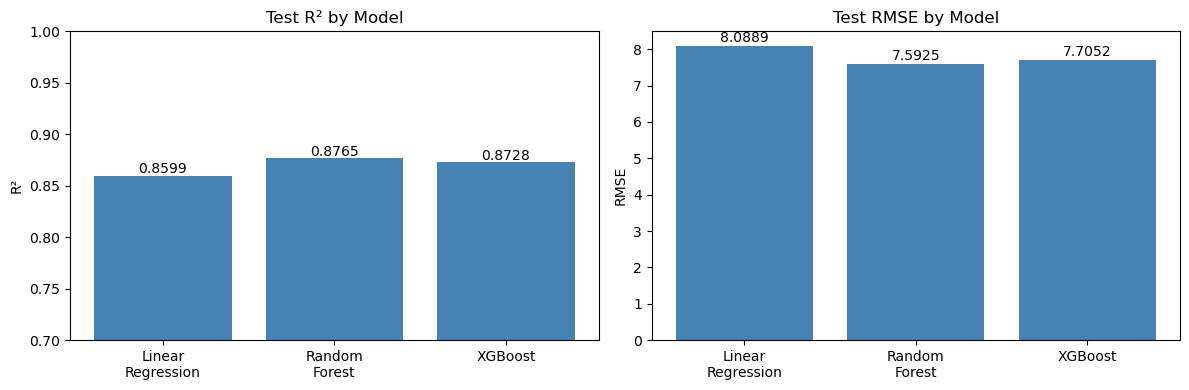

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models     = ['Linear\nRegression', 'Random\nForest', 'XGBoost']
test_r2s   = [r2_test_lr,    r2_test_rf,    r2_test_xgb]
test_rmses = [rmse_test_lr,  rmse_test_rf,  rmse_test_xgb]

axes[0].bar(models, test_r2s, color='steelblue')
axes[0].set_title('Test R² by Model')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.7, 1.0)
for i, v in enumerate(test_r2s):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(models, test_rmses, color='steelblue')
axes[1].set_title('Test RMSE by Model')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(test_rmses):
    axes[1].text(i, v + 0.1, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Actual vs Predicted Plots

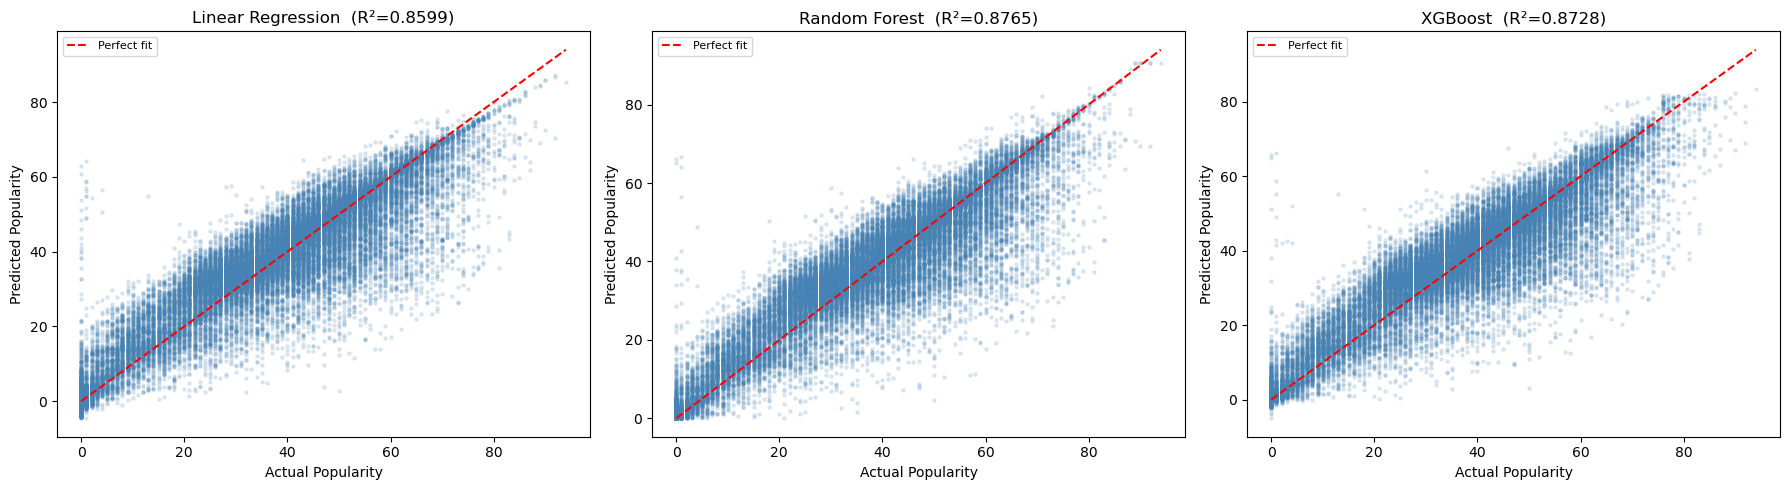

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(
    axes,
    [y_test_pred_lr, y_test_pred_rf, y_test_pred_xgb],
    ['Linear Regression', 'Random Forest', 'XGBoost']
):
    r2 = r2_score(y_test, y_pred)
    mn, mx = int(y_test.min()), int(y_test.max())
    ax.scatter(y_test, y_pred, alpha=0.15, s=5, color='steelblue')
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{title}  (R²={r2:.4f})')
    ax.set_xlabel('Actual Popularity')
    ax.set_ylabel('Predicted Popularity')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Residuals Analysis

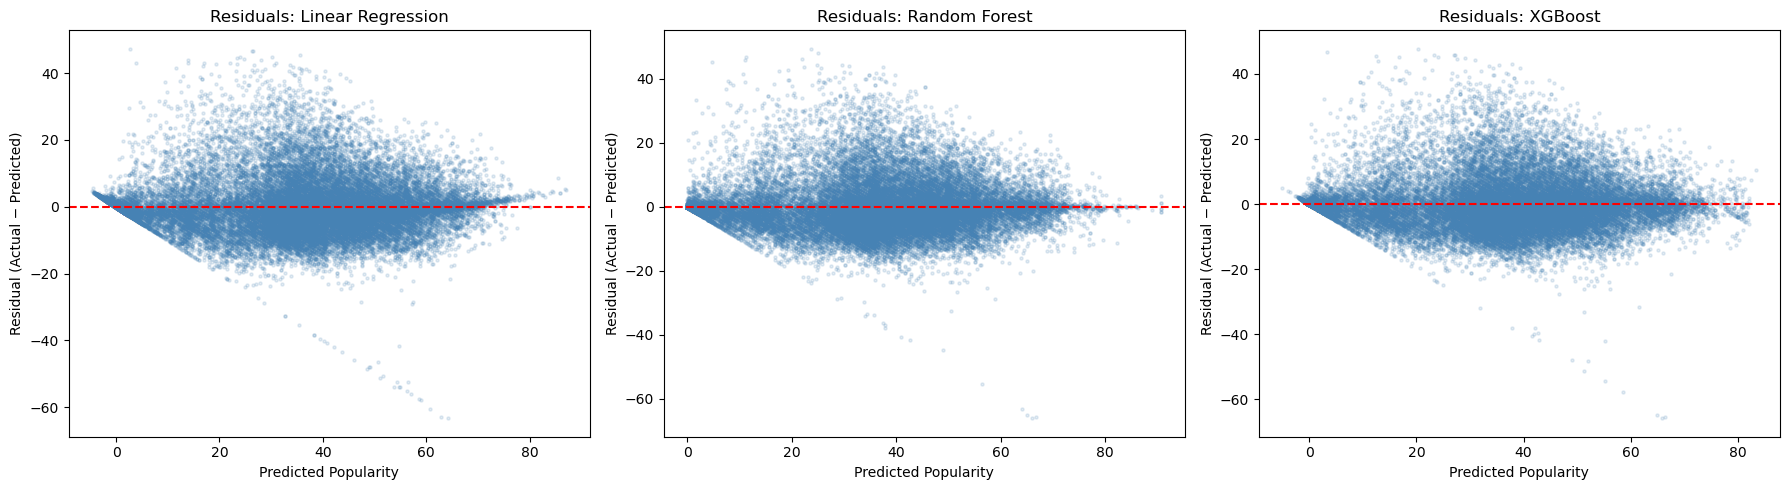

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(
    axes,
    [y_test_pred_lr, y_test_pred_rf, y_test_pred_xgb],
    ['Linear Regression', 'Random Forest', 'XGBoost']
):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.15, s=5, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.set_title(f'Residuals: {title}')
    ax.set_xlabel('Predicted Popularity')
    ax.set_ylabel('Residual (Actual − Predicted)')

plt.tight_layout()
plt.show()

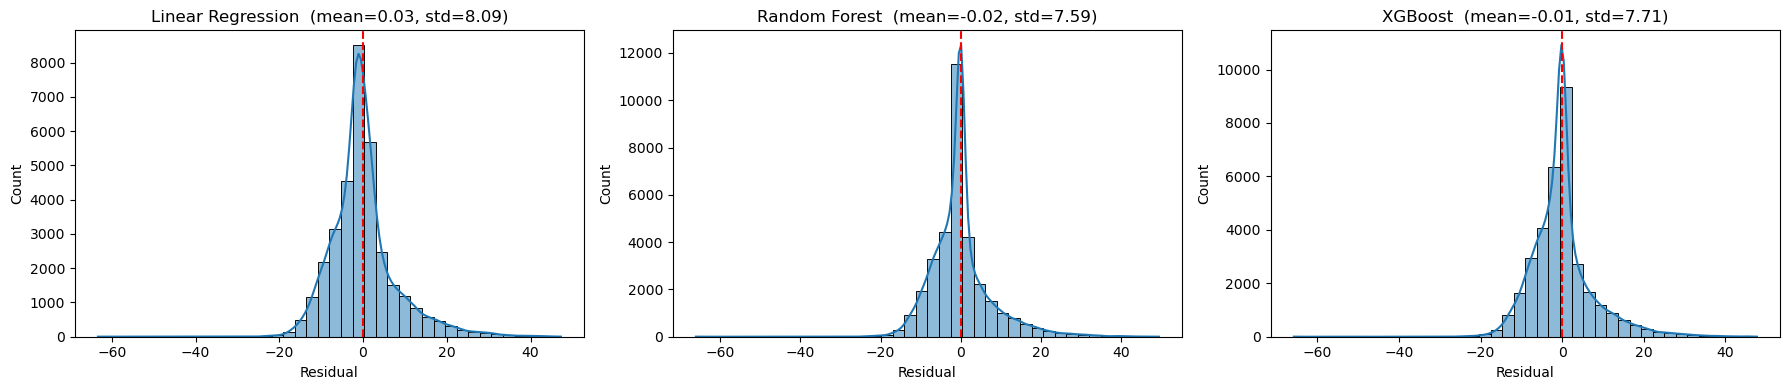

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, y_pred, title in zip(
    axes,
    [y_test_pred_lr, y_test_pred_rf, y_test_pred_xgb],
    ['Linear Regression', 'Random Forest', 'XGBoost']
):
    residuals = y_test - y_pred
    sns.histplot(residuals, bins=40, kde=True, ax=ax)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'{title}  (mean={residuals.mean():.2f}, std={residuals.std():.2f})')
    ax.set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 10. Overfitting Check

In [13]:
model_names = ['Linear Regression', 'Random Forest', 'XGBoost']
train_r2s   = [r2_train_lr,   r2_train_rf,   r2_train_xgb]
test_r2s    = [r2_test_lr,    r2_test_rf,    r2_test_xgb]

print(f"{'Model':<22} {'Train R²':>9} {'Test R²':>9} {'Gap':>7}  Status")
print('-' * 58)
for name, tr, te in zip(model_names, train_r2s, test_r2s):
    gap  = tr - te
    flag = '⚠  Overfitting' if gap > 0.05 else '✓  OK'
    print(f'{name:<22} {tr:>9.4f} {te:>9.4f} {gap:>7.4f}  {flag}')

Model                   Train R²   Test R²     Gap  Status
----------------------------------------------------------
Linear Regression         0.8619    0.8599  0.0021  ✓  OK
Random Forest             0.9060    0.8765  0.0295  ✓  OK
XGBoost                   0.8943    0.8728  0.0215  ✓  OK


## 11. Feature Importance — Random Forest

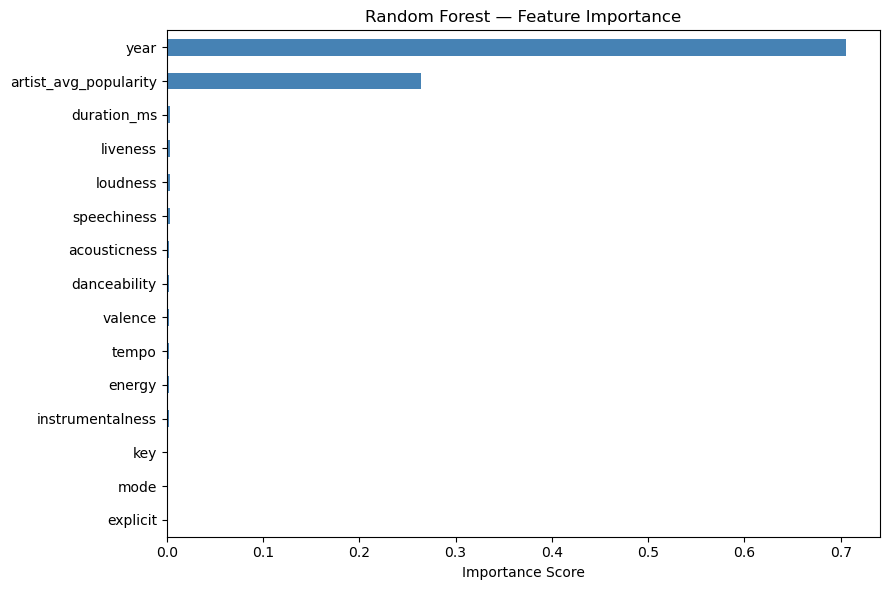

Top 5 features:
year                     0.7055
artist_avg_popularity    0.2642
duration_ms              0.0039
liveness                 0.0032
loudness                 0.0032


In [14]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Random Forest — Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(feat_imp.sort_values(ascending=False).head(5).round(4).to_string())

## Summary

| Model | Test R² | Test RMSE | Train–Test Gap | Notes |
|---|---|---|---|---|
| Linear Regression | — | — | — | Baseline |
| Random Forest | — | — | — | Best Test R² |
| XGBoost | — | — | — | Close to RF |

*(Fill in the actual numbers from the results table above after running the notebook.)*

**Key findings:**
- Tree-based models outperform linear regression because they capture non-linear interactions between features.
- `artist_avg_popularity` is the dominant feature in both Random Forest and XGBoost — confirming the finding from Notebook 3.
- Random Forest with `max_depth=15, min_samples_leaf=10` generalises well — the train–test gap stays small.
- XGBoost performs similarly to Random Forest with default parameters.
